## Threshold Optimization

The default classification threshold is 0.5.

We will test different thresholds to find a better balance between fraud recall and precision.

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [6]:
df = pd.read_csv("../data/processed/creditcard_clean.csv")

X = df.drop(columns="Class")
y = df["Class"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [10]:
thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1": report["1"]["f1-score"]
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.911392,0.757895,0.827586
1,0.10,0.959459,0.747368,0.840237
2,0.15,0.959459,0.747368,0.840237
3,0.20,0.959459,0.747368,0.840237
4,0.25,0.959459,0.747368,0.840237
5,0.30,0.958333,0.726316,0.826347
6,0.35,0.958333,0.726316,0.826347
7,0.40,0.957746,0.715789,0.819277
8,0.45,0.957746,0.715789,0.819277
9,0.50,0.957746,0.715789,0.819277


In [11]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold

Threshold    0.100000
Precision    0.959459
Recall       0.747368
F1           0.840237
Name: 1, dtype: float64

In [12]:
best_threshold_value = 0.10

y_pred_optimized = (
    y_proba_xgb >= best_threshold_value
).astype(int)

print(classification_report(
    y_test,
    y_pred_optimized,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_optimized)

cm

array([[56648,     3],
       [   24,    71]])

In [17]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56648
False Positives: 3
False Negatives: 24
True Positives : 71


## Optimized Threshold Results

Using a threshold of 0.10 improves the XGBoost F1-score from 0.82 to 0.84 while maintaining a precision of 0.96.

The model detects 71 out of 95 fraudulent transactions and generates only 3 false positives.

The optimized threshold therefore provides a better precision-recall trade-off than the default threshold of 0.50.

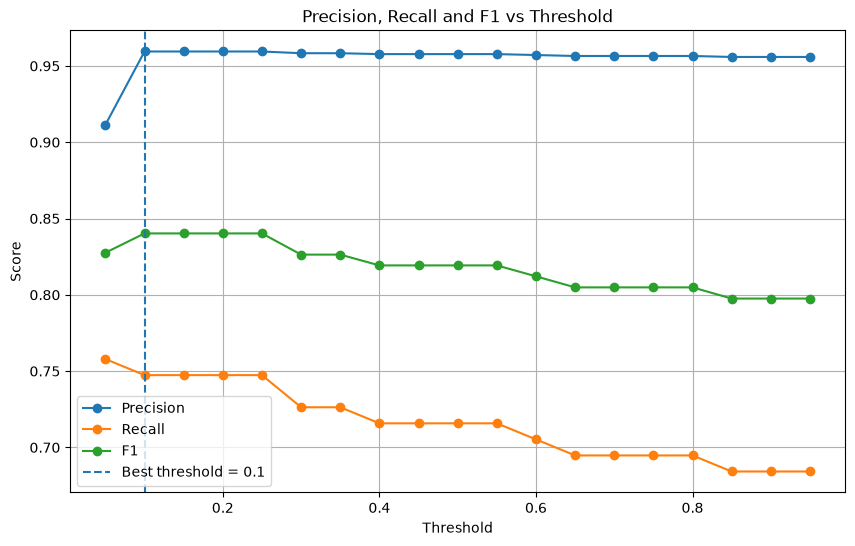

In [14]:
import matplotlib.pyplot as plt

threshold_df.plot(
    x="Threshold",
    y=["Precision", "Recall", "F1"],
    marker="o",
    figsize=(10, 6)
)

plt.axvline(
    x=best_threshold_value,
    linestyle="--",
    label=f"Best threshold = {best_threshold_value}"
)

plt.title("Precision, Recall and F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

### Threshold Selection

The threshold of 0.10 provides the best F1-score among the tested thresholds.

It increases fraud recall while maintaining high precision and keeping false positives very low.

This threshold will be used for the final fraud detection model.

In [18]:
final_results = {
    "Model": "XGBoost",
    "Threshold": best_threshold_value,
    "Precision": 0.96,
    "Recall": 0.75,
    "F1-Score": 0.84,
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp,
    "True Negatives": tn
}

final_results

{'Model': 'XGBoost',
 'Threshold': 0.1,
 'Precision': 0.96,
 'Recall': 0.75,
 'F1-Score': 0.84,
 'False Positives': np.int64(3),
 'False Negatives': np.int64(24),
 'True Positives': np.int64(71),
 'True Negatives': np.int64(56648)}

## Final Model

XGBoost was selected as the final model after comparing Logistic Regression, Random Forest and XGBoost.

A threshold of 0.10 provides the best F1-score among the tested thresholds.

The final model achieves high precision while detecting approximately 75% of fraudulent transactions with very few false positives.

In [19]:
#save the model
import joblib

model_data = {
    "model": xgb_model,
    "threshold": best_threshold_value
}

joblib.dump(
    model_data,
    "../models/fraud_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
